# 01 — Continued Pre-Training (CPT)

**Goal:** teach the base model brand-new *knowledge* by continuing pretraining on
a raw domain corpus — then watch it absorb vocabulary it had never seen.

This is stage **1** of the pipeline. CPT comes first because it changes what the
model *knows*; later stages change how it *behaves*. The resulting LoRA
adapter is saved to `checkpoints/cpt/`, and `02_sft` starts from it.

> Prerequisite: run `00_setup_and_base_model.ipynb` once to confirm the
> environment loads the model. This notebook is self-contained and re-loads it.

## The idea

**Continued Pre-Training is just pre-training, continued.** Same objective as the
original model: predict the next token. The differences are only:

- the data is **raw text** from a target domain (no prompt/response structure), and
- the loss is computed on **every token** (there is nothing to mask).

\[ \mathcal{L}_{\text{CPT}} = -\sum_{t} \log p_\theta(x_t \mid x_{<t}) \]

This is identical to the loss SFT will use — the *only* difference there will be
label masking. Seeing both makes that contrast concrete.

### Catastrophic forgetting

Training hard on a narrow corpus can overwrite general abilities. Standard
mitigations, all visible here:

- **LoRA** — only a tiny low-rank adapter is nudged; the base weights stay frozen,
  so the original capabilities are structurally preserved.
- **Low learning rate** — small steps drift less from the pretrained solution.
- **Replay** (mention) — mixing in general-domain text would further reduce
  forgetting; it is skipped here to keep the toy run focused, but it's the
  standard fix.

Because the corpus is tiny and intentionally full of invented words
(*lumens, sablecores, dawnglass…*), "learning the domain" here mostly means
**absorbing new vocabulary and phrasing** — which is exactly what the run shows.

In [ ]:
import sys, pathlib

REPO_ROOT = pathlib.Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import torch
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer

from src.utils import (set_seed, get_device, amp_context, LossLogger,
                       plot_curves, read_jsonl, save_lora_checkpoint)
from src.lora import inject_lora, lora_parameters, count_parameters
from src.losses import causal_lm_loss
from src.data import CPTDataset

set_seed(42)
device = get_device()
MODEL_NAME = "HuggingFaceTB/SmolLM2-135M"
DATA_DIR = REPO_ROOT / "data"
CKPT_DIR = REPO_ROOT / "checkpoints"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float32)
inject_lora(model, target_modules=("q_proj", "v_proj"), r=8, alpha=16)
model.to(device)

trainable, total = count_parameters(model)
print(f"Device: {device} | trainable {trainable:,} / {total:,} "
      f"({100*trainable/total:.3f}%)")

/Users/jorgesandoval/code/llm-post-training-from-scratch/.venv/lib/python3.12/site-packages/transformers/utils/hub.py:127: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Device: mps | trainable 460,800 / 134,975,808 (0.341%)


## Capture "before" generations

Records what the model writes about the domain *before* training, for comparison
afterward. With the LoRA at init (`B = 0`) this is exactly the base model.

In [ ]:
@torch.no_grad()
def generate(model, prompt, max_new_tokens=50, temperature=0.0):
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    out = model.generate(
        **inputs, max_new_tokens=max_new_tokens,
        do_sample=temperature > 0,
        temperature=temperature if temperature > 0 else None,
        top_p=0.95 if temperature > 0 else None,
        pad_token_id=tokenizer.pad_token_id,
    )
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:],
                            skip_special_tokens=True).strip()


PROBE_PROMPTS = [
    "A lumenwright is",
    "In the city of Solgrove, dawnglass is",
    "When a lumen loses its glow it is called",
]
before = {p: generate(model, p) for p in PROBE_PROMPTS}
for p, t in before.items():
    print(f"[{p}]\n  -> {t}\n")

[A lumenwright is]
  -> a person who designs and builds lumen windows.

Lumen windows are designed to be used in a variety of applications, including:

  • Windows for the interior of a building
  • Windows for the exterior of a building
  • Windows for

[In the city of Solgrove, dawnglass is]
  -> a popular form of art.

The art of the dawnglass is a form of art that is practiced in the city of Solgrove, in the county of Cornwall, England. The art is practiced by the people of Solgrove,

[When a lumen loses its glow it is called]
  -> a lumen-dimming lamp.

Lumen-dimming lamps are used in the home to reduce the amount of light that is emitted from a light bulb. They are also used in the workplace to reduce the amount of light that is



## Build the CPT dataset

`CPTDataset` (in `src/data.py`) concatenates all documents (separated by EOS) and
chops the token stream into fixed-length blocks. Crucially, **`labels` are a copy
of `input_ids`** — every token is a prediction target. There is no prompt to mask.

In [ ]:
BLOCK_SIZE = 128
BATCH_SIZE = 4

corpus = [row["text"] for row in read_jsonl(DATA_DIR / "cpt_corpus.jsonl")]
dataset = CPTDataset(corpus, tokenizer, block_size=BLOCK_SIZE)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Documents: {len(corpus)} | blocks of {BLOCK_SIZE} tokens: {len(dataset)}")
sample = dataset[0]
print("input_ids[:12] :", sample["input_ids"][:12].tolist())
print("labels[:12]    :", sample["labels"][:12].tolist())
print("labels == input_ids ?", torch.equal(sample["input_ids"], sample["labels"]))

Documents: 51 | blocks of 128 tokens: 19
input_ids[:12] : [788, 260, 22351, 766, 2240, 282, 4681, 87, 15970, 28, 253, 303]
labels[:12]    : [788, 260, 22351, 766, 2240, 282, 4681, 87, 15970, 28, 253, 303]
labels == input_ids ? True


## The training loop (from scratch)

A plain PyTorch loop: forward → `causal_lm_loss` → backward → step. The loss
function lives in `src/losses.py`; note it internally shifts logits/labels so
token *t* predicts token *t+1*. Only the LoRA parameters are optimized.

`amp_context(device)` enables bf16 autocast on CUDA and is a no-op on Metal/CPU,
so the same loop runs on a MacBook and on RunPod unchanged.

In [ ]:
EPOCHS = 40
LR = 3e-4

optimizer = torch.optim.AdamW(lora_parameters(model), lr=LR)
logger = LossLogger()

model.train()
step = 0
for epoch in range(EPOCHS):
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        attn = torch.ones_like(input_ids)

        with amp_context(device):
            logits = model(input_ids=input_ids, attention_mask=attn).logits
            loss = causal_lm_loss(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lora_parameters(model), 1.0)
        optimizer.step()

        logger.log(step, loss=loss.item())
        step += 1
    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        print(f"epoch {epoch:3d} | step {step:4d} | loss {loss.item():.4f}")

print(f"\nFinal loss: {logger.last('loss'):.4f}")

epoch   0 | step    5 | loss 4.7756


epoch   5 | step   30 | loss 4.2230


epoch  10 | step   55 | loss 3.7720


epoch  15 | step   80 | loss 3.3190


epoch  20 | step  105 | loss 2.8048


epoch  25 | step  130 | loss 2.4849


epoch  30 | step  155 | loss 2.3181


epoch  35 | step  180 | loss 1.7323


epoch  39 | step  200 | loss 1.7247

Final loss: 1.7247


## Loss curve

The loss should fall steadily as the adapter memorizes the domain's statistics.
On such a tiny corpus it will drop quite low — that's expected and fine for a
didactic demonstration of *absorption*.

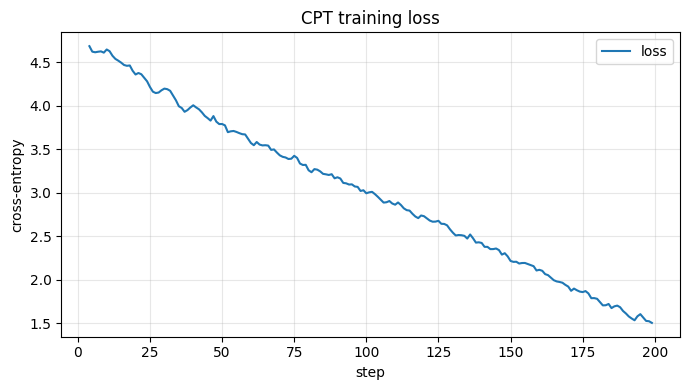

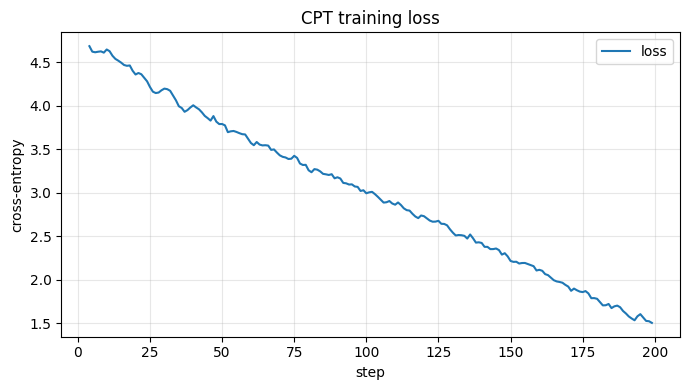

In [ ]:
fig = plot_curves(logger, ["loss"], title="CPT training loss",
                  ylabel="cross-entropy", smooth=5)
fig

## Before vs after: vocabulary absorption

Same prompts as before. The post-CPT model should now continue them using the
domain's invented vocabulary and lore, instead of generic guesses. (It's still
*not* an instruction-follower — that's SFT's job in the next notebook.)

In [ ]:
after = {p: generate(model, p) for p in PROBE_PROMPTS}
for p in PROBE_PROMPTS:
    print(f"PROMPT: {p}")
    print(f"  BEFORE: {before[p]}")
    print(f"  AFTER : {after[p]}\n")

PROMPT: A lumenwright is
  BEFORE: a person who designs and builds lumen windows.

Lumen windows are designed to be used in a variety of applications, including:

  • Windows for the interior of a building
  • Windows for the exterior of a building
  • Windows for
  AFTER : called a lumenkeeper. A keeper who keeps a lumen keeps a lumen. A keeper who lumened a lumen may open a lumen, but a keeper who lumened a lumen might not. A keeper who l

PROMPT: In the city of Solgrove, dawnglass is
  BEFORE: a popular form of art.

The art of the dawnglass is a form of art that is practiced in the city of Solgrove, in the county of Cornwall, England. The art is practiced by the people of Solgrove,
  AFTER : taught as the only way to see the city. Guided by a single old keeper called the dawnkeeper, the whole community wear the tuneful tunlebarrows as their uniform.

PROMPT: When a lumen loses its glow it is called
  BEFORE: a lumen-dimming lamp.

Lumen-dimming lamps are used in the home to reduce 

## Save the LoRA checkpoint

Only the LoRA factors (a few MB) are persisted to `checkpoints/cpt/`. The next
stage (`02_sft`) loads this adapter so the pipeline is truly chained.

In [ ]:
ckpt_path = save_lora_checkpoint(
    model, CKPT_DIR / "cpt" / "adapter.pt",
    metadata={"stage": "cpt", "epochs": EPOCHS, "lr": LR,
              "block_size": BLOCK_SIZE, "final_loss": logger.last("loss")},
)
print("Saved:", ckpt_path)

Saved: /Users/jorgesandoval/code/llm-post-training-from-scratch/checkpoints/cpt/adapter.pt


## Recap & what's next

- Trained the LoRA adapter with a plain **next-token loss over all tokens**.
- Watched the model **absorb the domain vocabulary** (before vs after).
- Saved the adapter to `checkpoints/cpt/adapter.pt`.

The model now *knows* the domain but still doesn't *follow instructions*.

➡️ **`02_sft.ipynb`** — Supervised Fine-Tuning: same loss, but with the
**prompt masked** so the model learns to produce responses on command. The CPT
adapter is loaded as the starting point.